In [1]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "graphviz",
#   "matplotlib",
#   "numpy",
#   "pandas",
#   "pymc",
#   "scipy",
#   "seaborn",
# ]
# ///


In [2]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("poster")

We generate some test data from $N(0,1)$:

In [3]:
from scipy.stats import norm
data = norm.rvs(size=100)
data

array([-1.40705399,  0.47855778, -0.09668042,  1.73340459, -0.0935003 ,
        1.51884902,  0.14321649, -0.97385946, -1.25932683, -0.11006569,
        0.39172028, -0.28017972, -1.1848513 ,  0.7813908 ,  1.21234791,
        0.58837838,  0.44120785, -1.31492176,  0.56251823, -1.17382197,
       -0.5036201 ,  0.66069273,  0.9170503 ,  0.0818321 , -0.39673409,
       -0.17703474,  0.622938  , -0.31216903, -0.76925065, -1.27985395,
        0.25207792, -0.71459936, -1.5035201 , -0.20299391,  1.9505443 ,
        1.82787502,  0.10564024, -0.65272199,  0.11243971,  1.32859278,
        1.07419161,  1.54344363,  0.47665397,  0.83532311, -1.16837571,
       -0.66616421, -1.5110644 , -0.88473802, -1.30381742,  1.09177324,
       -0.34623827,  1.04072798, -0.40245543, -0.93406504, -0.23590713,
       -0.90397347, -2.04925936,  1.19272474,  0.72976297,  0.12442893,
       -1.38611462, -1.11220143, -1.41744909, -0.26507423,  0.46588182,
       -1.33920462, -1.44011436, -0.62538301, -0.54746824,  2.14

We fit this data using the following model:

$$
y \sim N(\mu, \sigma)\\
\mu = \alpha_1 + \alpha_2\\
\alpha_1 \sim Unif(-\infty, \infty)\\
\alpha_2 \sim Unif(-\infty, \infty)\\
\sigma \sim HalfCauchy(0,1)
$$

In [4]:
import pymc as pm
import arviz as az

In our sampler, we have chosen `cores=2` which allows us to run on multiple processes, generating two separate chains.

In [5]:
with pm.Model() as ni:
    sigma = pm.HalfCauchy("sigma", beta=1)
    alpha1=pm.Uniform('alpha1', lower=-10**6, upper=10**6)
    alpha2=pm.Uniform('alpha2', lower=-10**6, upper=10**6)
    mu = pm.Deterministic("mu", alpha1 + alpha2)
    y = pm.Normal("data", mu=mu, sigma=sigma, observed=data)
    stepper=pm.Metropolis()
    traceni = pm.sample(100000, step=stepper, cores=2)

Multiprocess sampling (2 chains in 2 jobs)


CompoundStep


>Metropolis: [sigma]


>Metropolis: [alpha1]


>Metropolis: [alpha2]


/Users/rahul/Library/Caches/uv/archive-v0/-9zMAs8POxRAxupzaV9ft/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 100_000 draw iterations (2_000 + 200_000 draws total) took 12 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


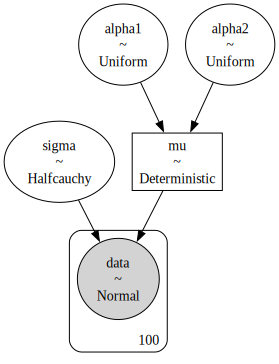

In [6]:
pm.model_to_graphviz(ni)

In [7]:
az.summary(traceni)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.979,0.070,0.850,1.111,0.000,0.000,25548.0,27098.0,1.00
alpha1,1.426,5.276,-9.282,8.457,3.263,1.436,3.0,26.0,1.73
alpha2,-1.429,5.275,-8.445,9.305,3.263,1.436,3.0,25.0,1.73
mu,-0.003,0.098,-0.181,0.186,0.001,0.000,26626.0,27051.0,1.00


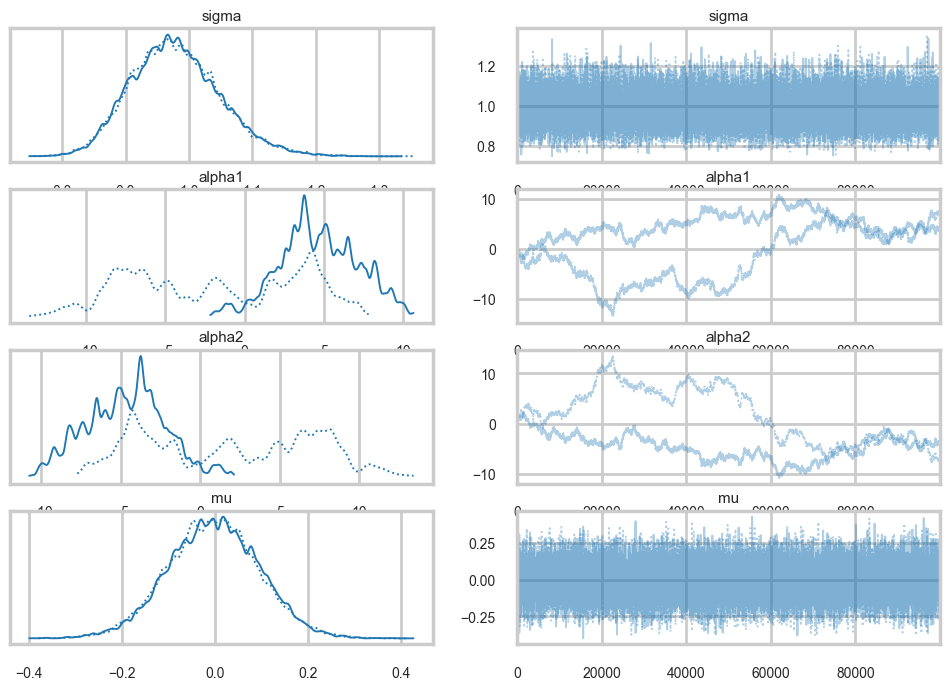

In [8]:
az.plot_trace(traceni);

Look at our traces for $\alpha_1$ and $\alpha_2$. These are bad, and worse, they look entirely different for two chains. Despite this, $\mu$ looks totally fine. Our trac

In [9]:
df=traceni.posterior.to_dataframe()
df.corr()

,sigma,alpha1,alpha2,mu
sigma,1.000000,0.002777,-0.002880,-0.005532
alpha1,0.002777,1.000000,-0.999828,0.021611
alpha2,-0.002880,-0.999828,1.000000,-0.003077
mu,-0.005532,0.021611,-0.003077,1.000000


Just like in our uncentered regression example, we have $\alpha_1$ and $\alpha_2$ sharing information: they are totally negatively correlated and unidentifiable. Indeed our intuition probably told us as much.

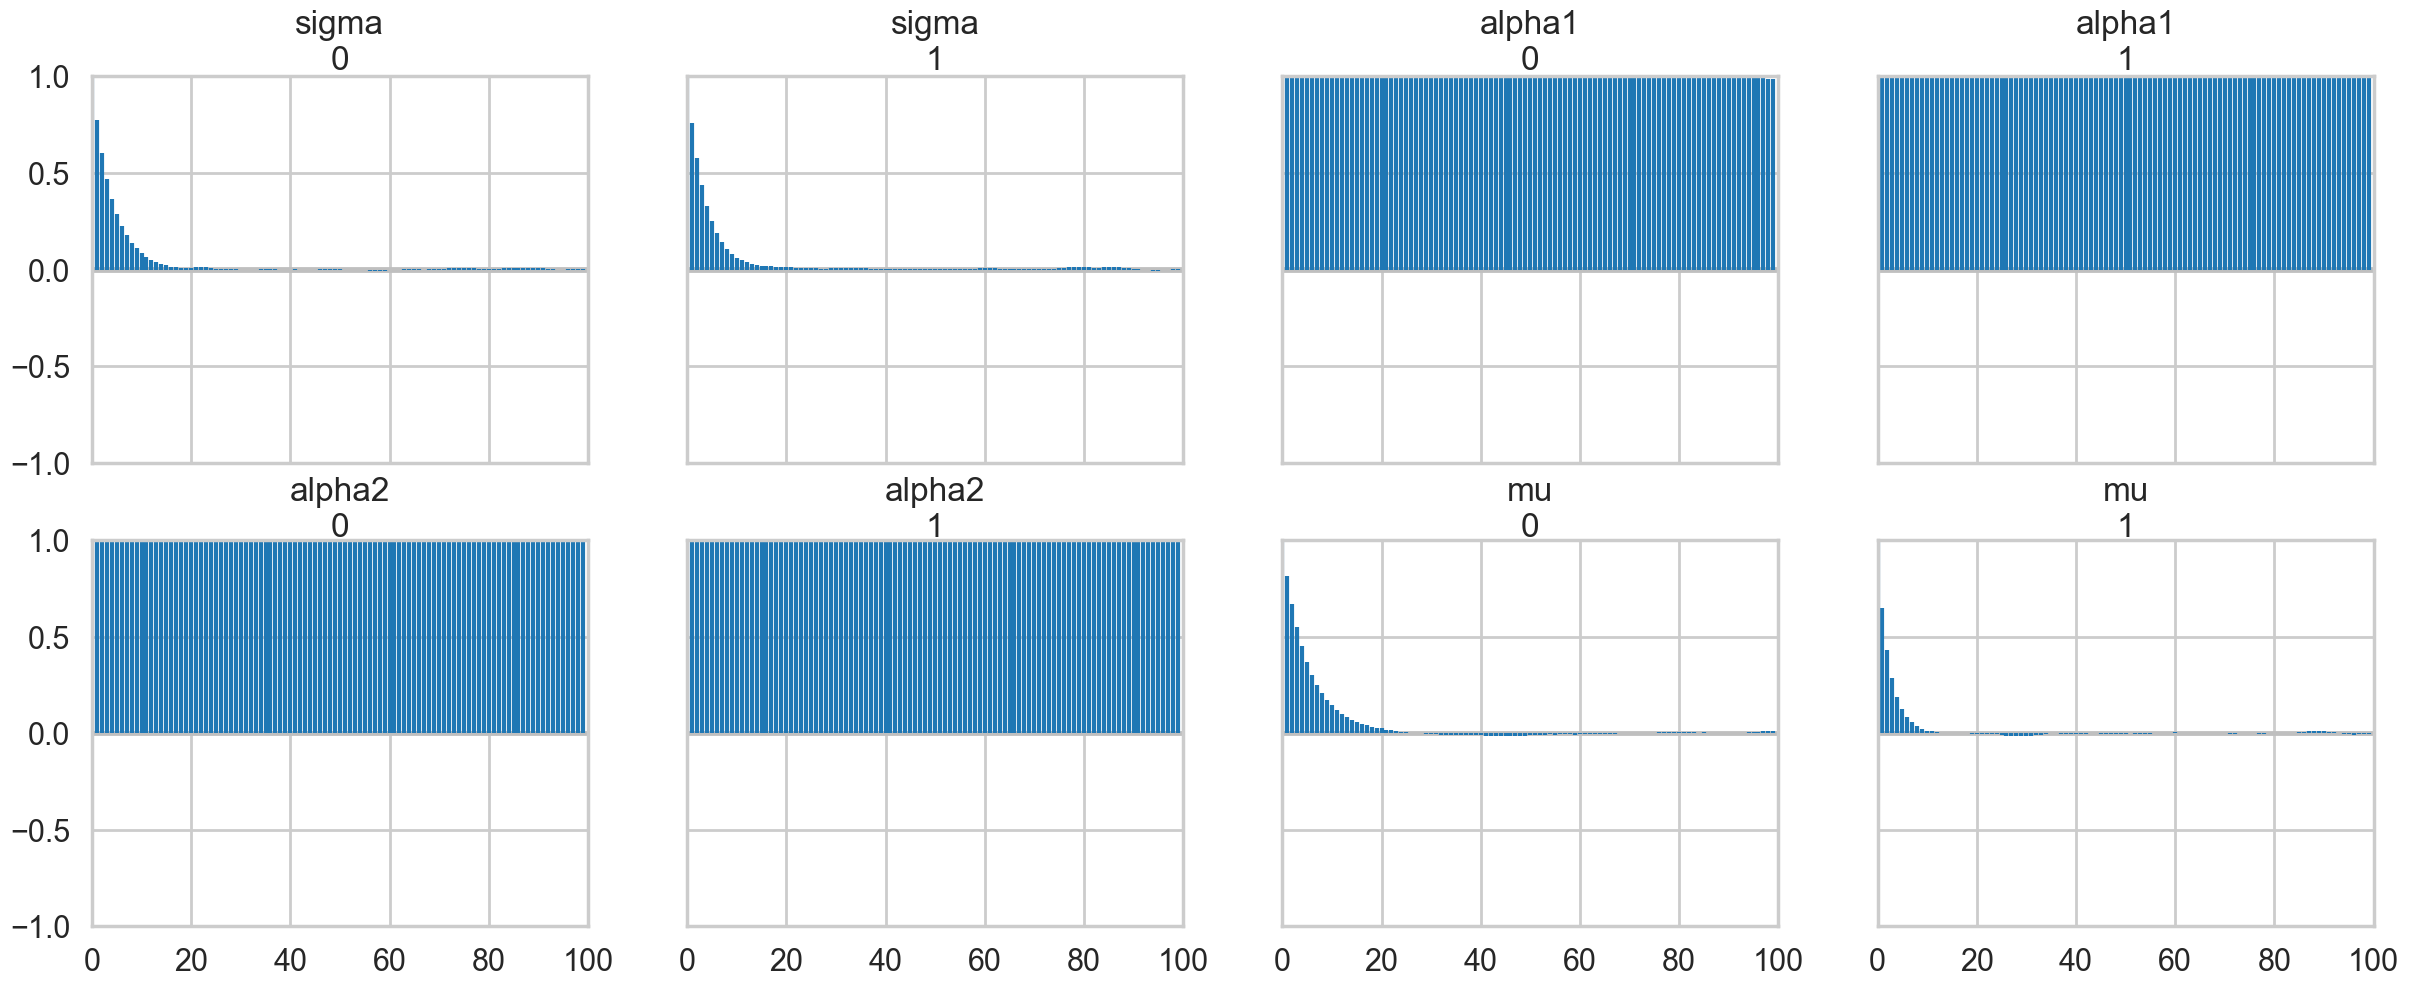

In [10]:
az.plot_autocorr(traceni);

A look at the effective number of samples using two chains tells us that we have only one effective sample for $\alpha_1$ and $\alpha_2$.

In [11]:
az.ess(traceni)

<xarray.Dataset> Size: 32B
Dimensions:  ()
Data variables:
    sigma    float64 8B 2.555e+04
    alpha1   float64 8B 3.074
    alpha2   float64 8B 3.073
    mu       float64 8B 2.663e+04
Attributes:
    created_at:                 2026-03-06T18:44:19.320198+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              12.227087020874023
    tuning_steps:               1000

The Gelman-Rubin statistic is awful for them. No convergence.

In [12]:
az.rhat(traceni)

<xarray.Dataset> Size: 32B
Dimensions:  ()
Data variables:
    sigma    float64 8B 1.0
    alpha1   float64 8B 1.731
    alpha2   float64 8B 1.732
    mu       float64 8B 1.0
Attributes:
    created_at:                 2026-03-06T18:44:19.320198+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              12.227087020874023
    tuning_steps:               1000

Its going to be hard to break this unidentifiability. We try by forcing $\alpha_2$ to be negative in our prior

In [13]:
with pm.Model() as ni2:
    sigma = pm.HalfCauchy("sigma", beta=1)
    alpha1=pm.Normal('alpha1', mu=5, sigma=1)
    alpha2=pm.Normal('alpha2', mu=-5, sigma=1)
    mu = pm.Deterministic("mu", alpha1 + alpha2)
    y = pm.Normal("data", mu=mu, sigma=sigma, observed=data)
    #stepper=pm.Metropolis()
    #traceni2 = pm.sample(100000, step=stepper, cores=2)
    traceni2 = pm.sample(100000)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, alpha1, alpha2]


/Users/rahul/Library/Caches/uv/archive-v0/-9zMAs8POxRAxupzaV9ft/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 100_000 draw iterations (4_000 + 400_000 draws total) took 66 seconds.


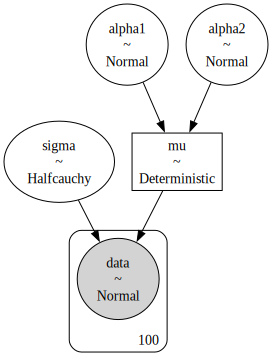

In [14]:
pm.model_to_graphviz(ni2)

Notice we are using the built in NUTS sampler. It takes longer but explores the distributions far better. This is directly related to our priors imposing regions. I could not even run the previous sampler in any reasonable time in NUTS.

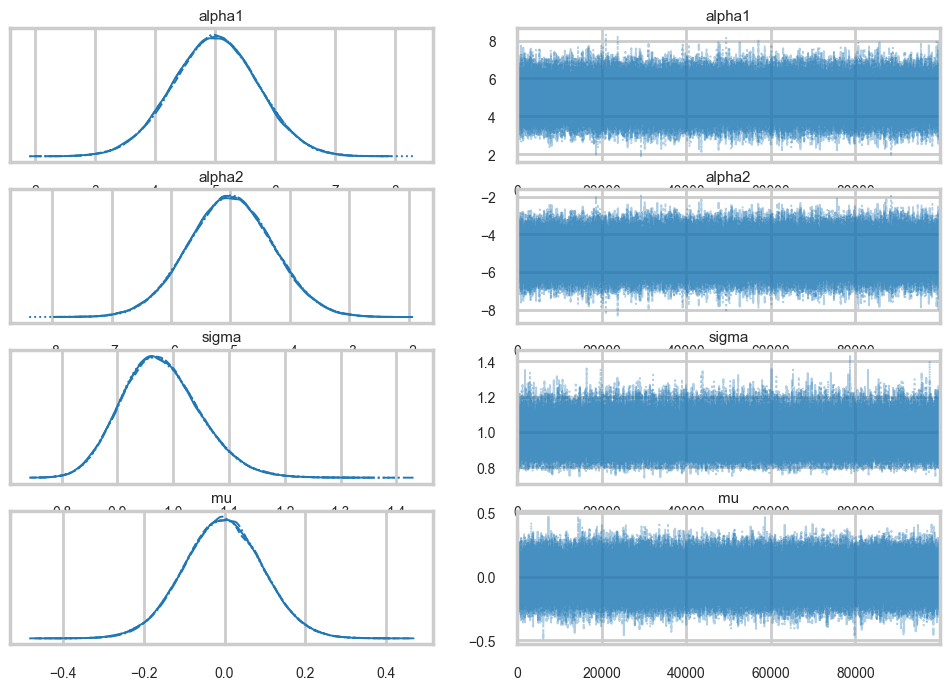

In [15]:
az.plot_trace(traceni2);

Our extremely strong priors have helped us do a much better job.

In [16]:
az.summary(traceni2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha1,5.000,0.710,3.679,6.354,0.002,0.002,127028.0,147579.0,1.0
alpha2,-5.003,0.710,-6.331,-3.655,0.002,0.002,127359.0,147791.0,1.0
sigma,0.979,0.070,0.849,1.111,0.000,0.000,176191.0,167933.0,1.0
mu,-0.004,0.098,-0.189,0.180,0.000,0.000,418836.0,308070.0,1.0


Our effective sample size is still poor and our traces still look dodgy, but things are better. 

In [17]:
az.ess(traceni2)

<xarray.Dataset> Size: 32B
Dimensions:  ()
Data variables:
    alpha1   float64 8B 1.27e+05
    alpha2   float64 8B 1.274e+05
    sigma    float64 8B 1.762e+05
    mu       float64 8B 4.188e+05
Attributes:
    created_at:                 2026-03-06T18:45:36.679458+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              66.3943829536438
    tuning_steps:               1000

In [18]:
az.rhat(traceni2)

<xarray.Dataset> Size: 32B
Dimensions:  ()
Data variables:
    alpha1   float64 8B 1.0
    alpha2   float64 8B 1.0
    sigma    float64 8B 1.0
    mu       float64 8B 1.0
Attributes:
    created_at:                 2026-03-06T18:45:36.679458+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1
    sampling_time:              66.3943829536438
    tuning_steps:               1000

..and this shows in our Gelman-Rubin statistics as well...

In [19]:
traceni2.posterior.to_dataframe().corr()

,alpha1,alpha2,sigma,mu
alpha1,1.000000,-0.990497,0.000240,0.063937
alpha2,-0.990497,1.000000,-0.000245,0.073925
sigma,0.000240,-0.000245,1.000000,-0.000042
mu,0.063937,0.073925,-0.000042,1.000000


..but our unidentifiability is still high when we look at the correlation. This reflects the fundamental un-identifiability and sharing of information in our model since $\mu = \alpha_1 +\alpha_2$: all the priors do is artificially peg one of the parameters. And once one is pegged the other is too because of the symmetry.